In [ ]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
np.random.seed(42)  # Fixed seed for fair comparison

In [2]:
# Currency parameters: spot, annual vol, annual drift
fx_pairs = {
    "EUR/USD":  {"spot": 1.0800, "vol": 0.085, "drift": 0.00},
    "USD/JPY":  {"spot": 148.50, "vol": 0.110, "drift": 0.01},
    "GBP/USD":  {"spot": 1.2700, "vol": 0.095, "drift": -0.005},
}

# Scenarios to compare: name, vol multiplier, drift offset
scenarios = {
    "Base Case":   {"vol_mult": 1.0, "drift_add": 0.00},
    "High Vol":    {"vol_mult": 1.5, "drift_add": 0.00},
    "Bullish USD": {"vol_mult": 1.0, "drift_add": -0.02},
}

# Simulation settings
t = 1/12       # 1 month
n_sim = 10000

In [6]:
# Cell 3: Run Simulations for All Combinations (FIXED)
results = []
curves = {}  # Store all simulated paths per pair & scenario

for pair, fx in fx_pairs.items():
    S0 = fx["spot"]
    base_vol = fx["vol"]
    base_drift = fx["drift"]
    curves[pair] = {}
    
    for scenario, s in scenarios.items():
        sigma = base_vol * s["vol_mult"]
        mu = base_drift + s["drift_add"]
        
        # Geometric Brownian Motion
        Z = np.random.normal(0, 1, n_sim)
        S_T = S0 * np.exp( (mu - 0.5*sigma**2)*t + sigma*np.sqrt(t)*Z )
        curves[pair][scenario] = S_T
        
        # Calculate probabilities first
        prob_down = np.mean(S_T < S0 * 0.98)   # < -2%
        prob_up   = np.mean(S_T > S0 * 1.02)   # > +2%
        
        # Append as formatted strings
        results.append([
            pair, scenario,
            round(np.mean(S_T), 4),
            round(np.median(S_T), 4),
            round(np.percentile(S_T, 5), 4),
            round(np.percentile(S_T, 95), 4),
            f"{prob_down:.1%}",
            f"{prob_up:.1%}"
        ])

# Summary table
cols = ["Pair","Scenario","Mean","Median","5th %ile","95th %ile","P < -2%","P > +2%"]
df = pd.DataFrame(results, columns=cols)
display(df)

,Pair,Scenario,Mean,Median,5th %ile,95th %ile,P < -2%,P > +2%
0,EUR/USD,Base Case,1.0804,1.0801,1.0379,1.1248,20.2%,21.2%
1,EUR/USD,High Vol,1.0795,1.0790,1.0169,1.1462,30.2%,28.5%
2,EUR/USD,Bullish USD,1.0780,1.0776,1.0351,1.1216,23.5%,18.9%
3,USD/JPY,Base Case,148.6546,148.5940,140.9487,156.5826,25.5%,27.2%
4,USD/JPY,High Vol,148.6394,148.5135,137.1008,160.6009,33.7%,34.0%
5,USD/JPY,Bullish USD,148.4287,148.3986,140.8664,156.1864,27.8%,25.5%
6,GBP/USD,Base Case,1.2694,1.2688,1.2130,1.3290,24.1%,22.8%
7,GBP/USD,High Vol,1.2697,1.2680,1.1846,1.3581,31.7%,30.2%
8,GBP/USD,Bullish USD,1.2672,1.2668,1.2110,1.3252,25.9%,21.0%


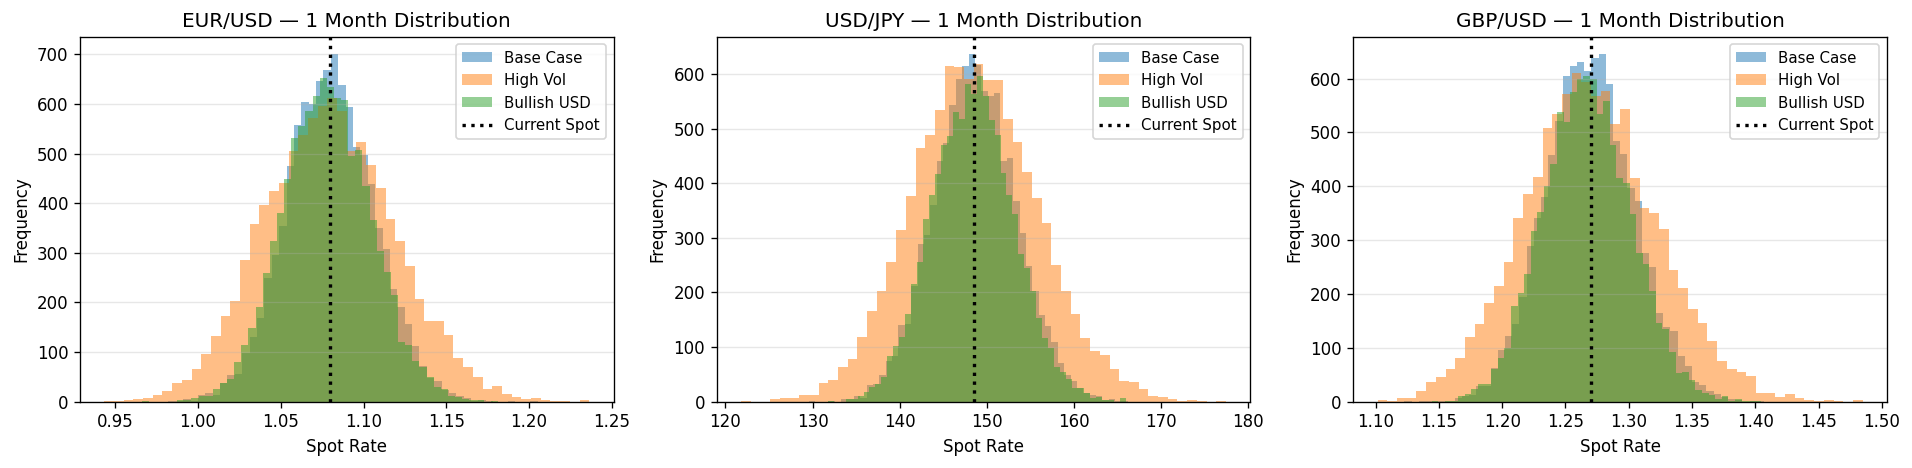

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

for idx, (pair, fx) in enumerate(fx_pairs.items()):
    ax = axes[idx]
    for s_idx, (scen, st) in enumerate(scenarios.items()):
        vals = curves[pair][scen]
        ax.hist(vals, bins=50, alpha=0.5, color=colors[s_idx], label=scen)
    
    ax.axvline(fx["spot"], color="black", ls=":", lw=2, label="Current Spot")
    ax.set_title(f"{pair} — 1 Month Distribution", fontsize=12)
    ax.set_xlabel("Spot Rate")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# Show only 90% range width + extreme move probability
summary_risk = df.pivot(
    index="Pair", columns="Scenario",
    values=["5th %ile","95th %ile","P < -2%","P > +2%"]
)
display(summary_risk.round(4))

5th %ile                       95th %ile                        \
Scenario Base Case Bullish USD  High Vol Base Case Bullish USD  High Vol   
Pair                                                                       
EUR/USD     1.0379      1.0351    1.0169    1.1248      1.1216    1.1462   
GBP/USD      1.213       1.211    1.1846     1.329      1.3252    1.3581   
USD/JPY   140.9487    140.8664  137.1008  156.5826    156.1864  160.6009   

           P < -2%                        P > +2%                       
Scenario Base Case Bullish USD High Vol Base Case Bullish USD High Vol  
Pair                                                                    
EUR/USD      20.2%       23.5%    30.2%     21.2%       18.9%    28.5%  
GBP/USD      24.1%       25.9%    31.7%     22.8%       21.0%    30.2%  
USD/JPY      25.5%       27.8%    33.7%     27.2%       25.5%    34.0%